In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar el archivo
data = pd.read_excel('/Bike_Sales_Outlier_Lab.xlsx')

# Mostrar las primeras filas
data.head()

,Sales_Order #,Date,Day,Month,Year,Customer_Age,Age_Group,Customer_Gender,Country,State,Product_Category,Sub_Category,Product_Description,Order_Quantity,Unit_Cost,Unit_Price,Profit,Cost,Revenue
0,261696,2021-12-01,1,December,2021,39,Adults (35-64),F,United States,California,Bikes,Mountain Bikes,"Mountain-200 Black, 46",4,1252,2295,4172,5008,9180
1,261695,2021-12-01,1,December,2021,44,Adults (35-64),M,United Kingdom,England,Bikes,Mountain Bikes,"Mountain-200 Silver, 42",1,1266,2320,1054,1266,2320
2,261697,2021-12-02,2,December,2021,37,Adults (35-64),M,United States,California,Bikes,Mountain Bikes,"Mountain-400-W Silver, 46",2,420,769,698,840,1538
3,261698,2021-12-02,2,December,2021,31,Young Adults (25-34),F,Australia,New South Wales,Bikes,Mountain Bikes,"Mountain-400-W Silver, 42",1,420,769,349,420,769
4,261699,2021-12-03,3,December,2021,37,Adults (35-64),F,United States,California,Bikes,Mountain Bikes,"Mountain-200 Black, 46",2,1252,2295,2086,2504,4590


In [2]:
# Agrupar las ventas por fecha
ventas_por_fecha = data.groupby('Date')['Order_Quantity'].sum().reset_index()

# Ordenar de mayor a menor
ventas_por_fecha = ventas_por_fecha.sort_values(
    by='Order_Quantity',
    ascending=False
)

# Mostrar las fechas con mayor cantidad de pedidos
ventas_por_fecha.head(10)

,Date,Order_Quantity
18,2021-12-19,43
17,2021-12-18,19
19,2021-12-20,13
11,2021-12-12,12
7,2021-12-08,11
4,2021-12-05,10
21,2021-12-22,10
9,2021-12-10,8
10,2021-12-11,8
6,2021-12-07,6


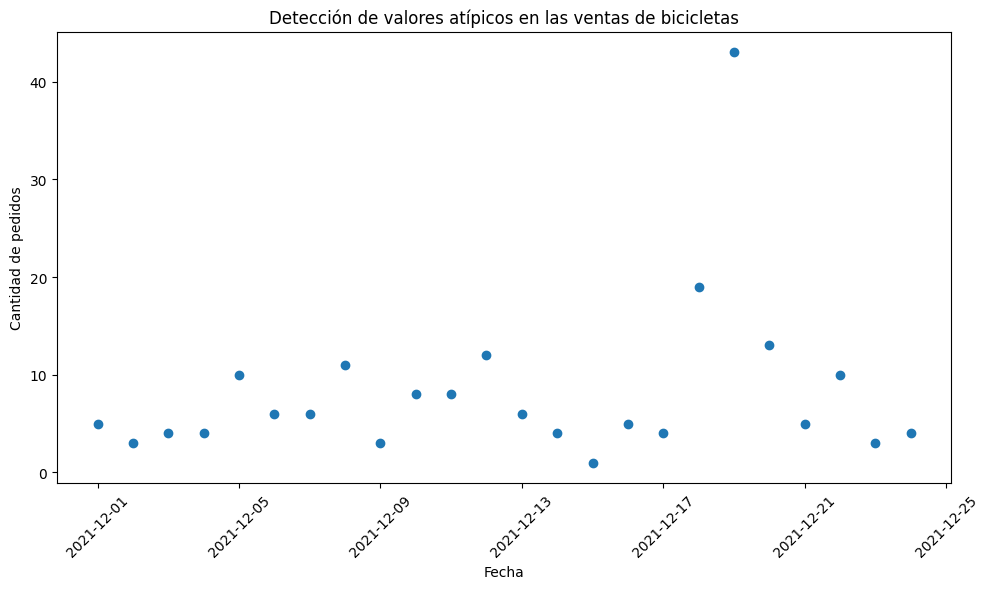

In [4]:
# Gráfico de dispersión para detectar el valor atípico

plt.figure(figsize=(10, 6))

plt.scatter(
    ventas_por_fecha['Date'],
    ventas_por_fecha['Order_Quantity']
)

plt.title('Detección de valores atípicos en las ventas de bicicletas')
plt.xlabel('Fecha')
plt.ylabel('Cantidad de pedidos')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [6]:
# Ver los nombres exactos de las columnas
print(data.columns.tolist())

['Sales_Order #', 'Date', 'Day', 'Month', 'Year', 'Customer_Age', 'Age_Group', 'Customer_Gender', 'Country', 'State', 'Product_Category', 'Sub_Category', 'Product_Description', 'Order_Quantity', ' Unit_Cost ', ' Unit_Price ', ' Profit ', ' Cost ', 'Revenue']


In [9]:
# Registros del 19 de diciembre de 2021
ventas_19 = data[data['Date'].astype(str).str.startswith('2021-12-19')]

# Ordenar por cantidad de pedido
ventas_19 = ventas_19.sort_values(
    by='Order_Quantity',
    ascending=False
)

# Mostrar todos los registros encontrados
ventas_19

,Sales_Order #,Date,Day,Month,Year,Customer_Age,Age_Group,Customer_Gender,Country,State,Product_Category,Sub_Category,Product_Description,Order_Quantity,Unit_Cost,Unit_Price,Profit,Cost,Revenue
70,261765,2021-12-19,19,December,2021,39,Adults (35-64),F,United States,Washington,Bikes,Mountain Bikes,"Mountain-200 Silver, 38",11,1266,2320,1054,13926,25520
61,261756,2021-12-19,19,December,2021,17,Youth (<25),M,France,Nord,Bikes,Mountain Bikes,"Mountain-200 Silver, 46",4,1266,2320,4216,5064,9280
62,261757,2021-12-19,19,December,2021,19,Youth (<25),F,Australia,Victoria,Bikes,Mountain Bikes,"Mountain-500 Black, 44",4,295,540,980,1180,2160
63,261758,2021-12-19,19,December,2021,25,Young Adults (25-34),M,France,Seine (Paris),Bikes,Mountain Bikes,"Mountain-200 Black, 38",4,1252,2295,4172,5008,9180
65,261760,2021-12-19,19,December,2021,37,Adults (35-64),M,United States,Oregon,Bikes,Mountain Bikes,"Mountain-200 Black, 38",4,1252,2295,4172,5008,9180
64,261759,2021-12-19,19,December,2021,35,Adults (35-64),F,United States,Oregon,Bikes,Mountain Bikes,"Mountain-100 Black, 48",4,1898,3375,5908,7592,13500
66,261761,2021-12-19,19,December,2021,39,Adults (35-64),F,United States,California,Bikes,Mountain Bikes,"Mountain-200 Black, 46",4,1252,2295,4172,5008,9180
67,261762,2021-12-19,19,December,2021,63,Adults (35-64),F,Australia,Queensland,Bikes,Mountain Bikes,"Mountain-200 Black, 46",4,1252,2295,4172,5008,9180
68,261763,2021-12-19,19,December,2021,18,Youth (<25),M,Australia,South Australia,Bikes,Mountain Bikes,"Mountain-500 Black, 40",2,295,540,490,590,1080
69,261764,2021-12-19,19,December,2021,56,Adults (35-64),F,Germany,Hessen,Bikes,Mountain Bikes,"Mountain-200 Black, 46",2,1252,2295,2086,2504,4590


In [10]:
# 5 valores más altos de Order_Quantity

valores_mayores = data['Order_Quantity'].nlargest(5)

print("Los 5 valores más altos son:")
print(valores_mayores.tolist())

Los 5 valores más altos son:
[11, 4, 4, 4, 4]


In [11]:
# 6 valores más bajos de Order_Quantity

valores_menores = data['Order_Quantity'].nsmallest(6)

print("Los 6 valores más bajos son:")
print(valores_menores.tolist())

Los 6 valores más bajos son:
[1, 1, 1, 1, 1, 1]


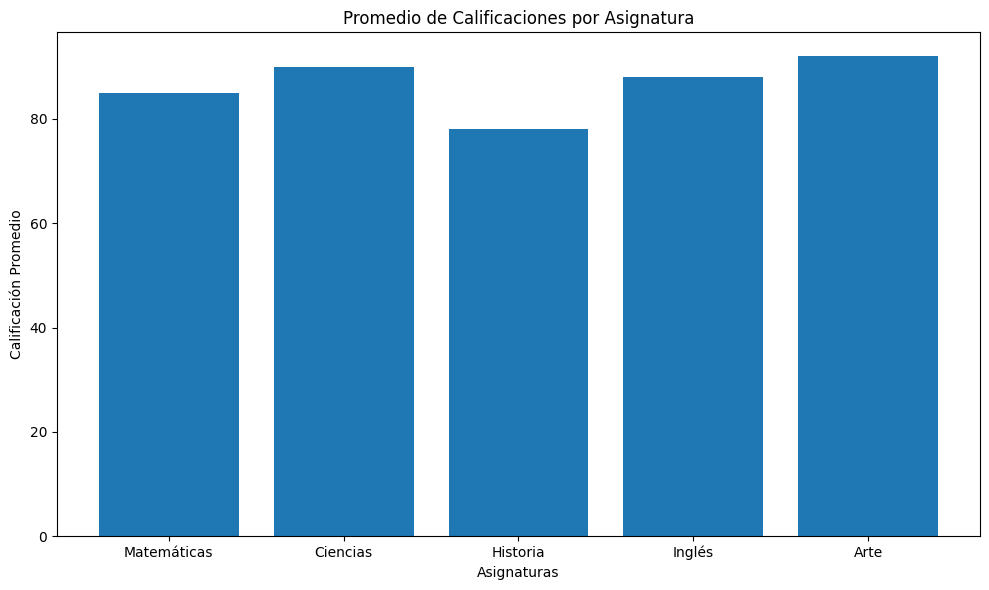

In [12]:
import matplotlib.pyplot as plt

# Datos
asignaturas = ['Matemáticas', 'Ciencias', 'Historia', 'Inglés', 'Arte']
calificaciones = [85, 90, 78, 88, 92]

# Gráfico de barras
plt.figure(figsize=(10, 6))
plt.bar(asignaturas, calificaciones)

plt.title('Promedio de Calificaciones por Asignatura')
plt.xlabel('Asignaturas')
plt.ylabel('Calificación Promedio')

plt.tight_layout()
plt.show()

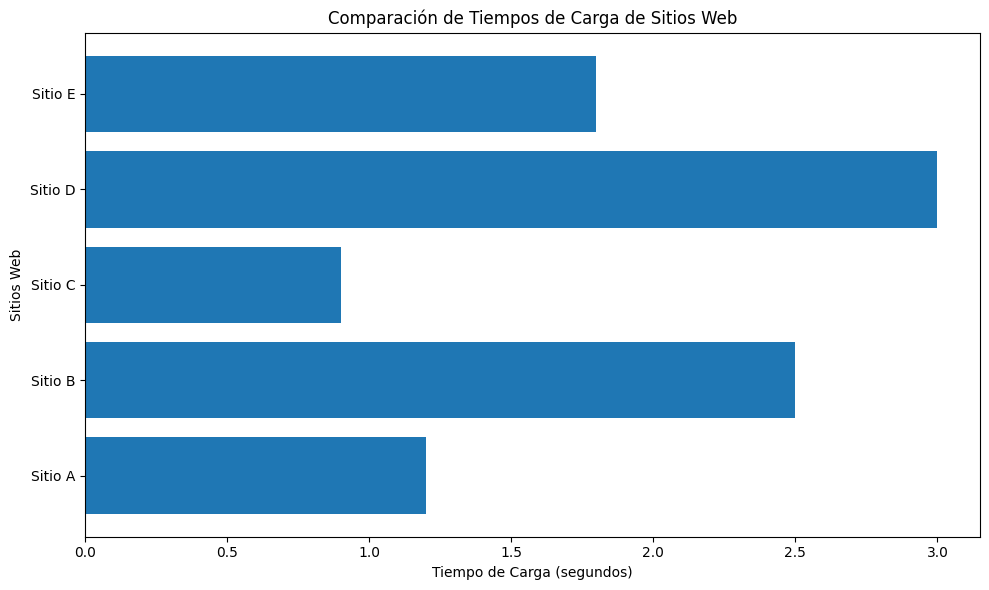

In [13]:
import matplotlib.pyplot as plt

# Datos
sitios = ['Sitio A', 'Sitio B', 'Sitio C', 'Sitio D', 'Sitio E']
tiempos = [1.2, 2.5, 0.9, 3.0, 1.8]

# Gráfico de barras horizontales
plt.figure(figsize=(10, 6))
plt.barh(sitios, tiempos)

plt.title('Comparación de Tiempos de Carga de Sitios Web')
plt.xlabel('Tiempo de Carga (segundos)')
plt.ylabel('Sitios Web')

plt.tight_layout()
plt.show()

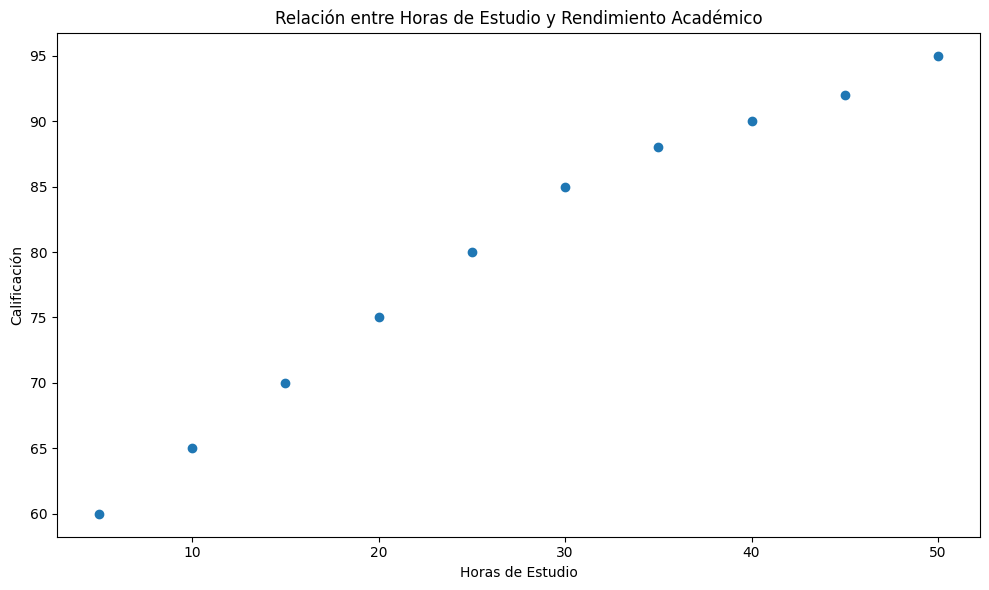

In [14]:
import matplotlib.pyplot as plt

# Datos
horas_estudio = [5, 10, 15, 20, 25, 30, 35, 40, 45, 50]
calificaciones = [60, 65, 70, 75, 80, 85, 88, 90, 92, 95]

# Gráfico de dispersión
plt.figure(figsize=(10, 6))
plt.scatter(horas_estudio, calificaciones)

plt.title('Relación entre Horas de Estudio y Rendimiento Académico')
plt.xlabel('Horas de Estudio')
plt.ylabel('Calificación')

plt.tight_layout()
plt.show()

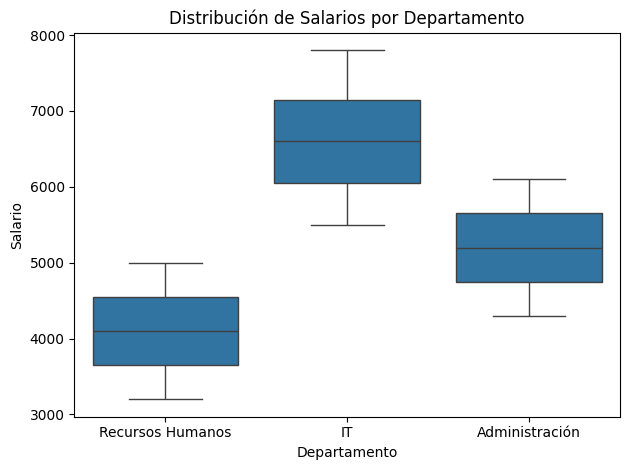

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Datos de salarios
datos_salarios = {
    'Departamento': ['Recursos Humanos']*10 + ['IT']*10 + ['Administración']*10,
    'Salario': [
        3200, 3400, 3600, 3800, 4000, 4200, 4400, 4600, 4800, 5000,
        5500, 5700, 6000, 6200, 6500, 6700, 7000, 7200, 7500, 7800,
        4300, 4500, 4700, 4900, 5100, 5300, 5500, 5700, 5900, 6100
    ]
}

df_salarios = pd.DataFrame(datos_salarios)

# Crear gráfico de cajas
sns.boxplot(
    x='Departamento',
    y='Salario',
    data=df_salarios
)

plt.title('Distribución de Salarios por Departamento')
plt.xlabel('Departamento')
plt.ylabel('Salario')

plt.tight_layout()
plt.show()

1. Interpretación del Ejercicio 1
El gráfico de barras muestra el rendimiento promedio en cada asignatura. Arte presenta la calificación promedio más alta con 92, seguida de Ciencias con 90. Historia presenta el promedio más bajo con 78.

2. Interpretación del Ejercicio 2
El gráfico de barras horizontales permite comparar los tiempos de carga de los diferentes sitios web. El Sitio C presenta el menor tiempo de carga, con 0,9 segundos, mientras que el Sitio D presenta el mayor tiempo, con 3,0 segundos.

3. Interpretación del Ejercicio 3
El gráfico de dispersión muestra una relación positiva entre las horas de estudio y las calificaciones. En los datos utilizados, al aumentar las horas de estudio también aumentan las calificaciones obtenidas.

4. Interpretación del Ejercicio 4
El gráfico de cajas muestra la distribución de los salarios en los tres departamentos. IT presenta la mediana salarial más alta, mientras que Recursos Humanos presenta la menor variabilidad de los salarios.